# solveit-tex

A utility for creating LaTeX papers using SolveIT, to facilitate Human-Authored, Computer-Interrogated (HACI) writing workflows.

The idea is to be able to work in Solvit and see somewhat of what you're working on and be able to interrogate it via the AI incrementally and then have it generate a paper.

Full interoperability between Solve It and LaTeX isn't entirely something I'm going for, but I'm trying to make it so that things that render In one medium, render in the other to as high a degree as possible.

In [ ]:
#| export
import os, subprocess, json, re, sys
from pathlib import Path
from IPython.display import HTML, display

## Utilities called by other routines

In [ ]:
#| export
async def get_curr_dialog_path():
    from dialoghelper.solveitskill import curr_dialog, realpath
    name = (await curr_dialog())['name']
    return f'{await realpath("/")}/{name}.ipynb'

In [ ]:
curr_dialog_path = await get_curr_dialog_path()
print(curr_dialog_path)
print(type(curr_dialog_path))

/app/data/solveit-tex/solveit-tex.ipynb


<class 'str'>


In [ ]:
#| export
def get_private_url(path: str):
    "Get the private URL for a file on the solveit cloud instance"
    server = os.getenv('PRIVATE_DOMAIN')
    if not server: raise ValueError("PRIVATE_DOMAIN not set")
    path = os.path.abspath(path)
    return f"https://{server}.solve.it.com{path.replace('/app/data', '/static')}"

In [ ]:
get_private_url(curr_dialog_path) 

'https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/solveit-tex.ipynb'

### Figures

In [ ]:
#| export
def parse_figure(line: str):
    r"""Parse markdown figure syntax with multiple images on one line: ![alt1](img1.png) ![alt2](img2.png)\{width=45% #fig:label}
     Images on one line get grouped into a single figure, with the final caption and label being the one used for the group"""
    import re
    
    # Look for escaped attributes at the end: \{...}
    attrs = ''
    attr_match = re.search(r'\\\{([^}]*)\}\s*$', line)
    if attr_match:
        attrs = attr_match.group(1)
        line = line[:attr_match.start()]  # Remove the attributes part
    
    # Find all image patterns on the line
    pattern = r'!\[([^\]]*)\]\(([^)]+)\)'
    matches = re.findall(pattern, line.strip())
    
    if not matches: return None
    
    images = []
    caption = ""
    
    for i, (alt, path) in enumerate(matches):
        img = {'path': path.strip()}
        images.append(img)
        
        # Last image sets the caption and label
        if i == len(matches) - 1:
            caption = alt
    
    # Extract width and label from attributes
    width_m = re.search(r'width=([^\s#]+)', attrs)
    label_m = re.search(r'#fig:([^\s}]+)', attrs)
    width = width_m.group(1) if width_m else None
    label = label_m.group(1) if label_m else None
    
    # Apply width to all images if specified
    if width:
        for img in images:
            img['width'] = width
    
    # If caption is just a filename, treat as no caption
    if caption:
        path_basenames = [Path(p['path']).name for p in images]
        if caption in path_basenames or caption in [p['path'] for p in images]:
            caption = ""
    
    return {'caption': caption, 'images': images, 'label': label}

In [ ]:
# Test it
s = r'![](images/mnist_ring_op_k_filmr_family.png) ![MNIST ring op$^k$ compositionality - FILMR \& Matrix Op](images/mnist_ring_op_k_mat_family.png)\{#fig:op_k}'
im_dict = parse_figure(s)
im_dict 

{'caption': 'MNIST ring op$^k$ compositionality - FILMR \\& Matrix Op',
 'images': [{'path': 'images/mnist_ring_op_k_filmr_family.png'},
  {'path': 'images/mnist_ring_op_k_mat_family.png'}],
 'label': 'op_k'}

In [ ]:
#| export
def make_figure(fig_dict: dict):
    "Generate LaTeX figure environment from image specs."
    images, caption, label = fig_dict['images'],  fig_dict.get('caption', ''), fig_dict.get('label', '')
    lines = ['\\begin{figure}[htbp]', '\\centering']  # Start figure environment
    for img in images:
        width_opt = f'[width={img["width"]}]' if 'width' in img else '[width=\\linewidth]' # Add width if specified, defalt to linewidth
        lines.append(f'\\includegraphics{width_opt}{{{img["path"]}}}')  # Include the image
    if caption: lines.append(f'\\caption{{{caption}}}')  # Add caption if provided
    if label: lines.append(f'\\label{{fig:{label}}}')  # Add label if provided
    lines.append('\\end{figure}')  # Close figure environment
    return '\n'.join(lines)

In [ ]:
fig_tex = make_figure(im_dict)
print(fig_tex)

\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{images/mnist_ring_op_k_filmr_family.png}
\includegraphics[width=\linewidth]{images/mnist_ring_op_k_mat_family.png}
\caption{MNIST ring op$^k$ compositionality - FILMR \& Matrix Op}
\label{fig:op_k}
\end{figure}


### Tables

In [ ]:
#| export
def parse_table(lines):
    """Parse markdown table with optional caption above or below. Returns table_dict or None.
    Note: parse table doesn't care whether the caption comes first or last, *however* logic of the main export script
    only triggers table conversion when the *first line* starts with "|".  So in Markdown, the caption needs to come last.
    """
    if isinstance(lines, str): lines = lines.split('\n')
    start = 0
    while start < len(lines) and not lines[start].strip(): start += 1
    lines = lines[start:]
    caption, label = '', None
    if not lines[0].strip().startswith('|'):
        m = re.match(r'\s*\*([^*]+)\*(?:\s*\\\{#([^}]+)\})?', lines[0])
        if m: caption, label = m.group(1), m.group(2); lines = lines[1:]
    if not lines or not lines[0].startswith('|'): return None
    i = 0
    while i < len(lines) and lines[i].startswith('|'): i += 1
    if i < 3: return None
    sep = [c.strip() for c in lines[1].split('|')[1:-1]]
    aligns = ['c' if c.startswith(':') and c.endswith(':') else 'r' if c.endswith(':') else 'l' for c in sep]
    headers = [c.strip() for c in lines[0].split('|')[1:-1]]
    rows = []
    for r in lines[2:i]:
        if r.strip().startswith('| ---'): rows.append(None)   # allow for midrules
        else: rows.append([c.strip() for c in r.split('|')[1:-1]])
    if i < len(lines):
        m = re.match(r'\s*\*([^*]+)\*(?:\s*\\\{#([^}]+)\})?', lines[i])
        if m: caption, label = m.group(1), m.group(2)
    return {'headers': headers, 'rows': rows, 'alignments': aligns, 'caption': caption, 'label': label}


In [ ]:
# test it
test_str = r"""
| lambda-neg | TEST MRR ↑ | H@1 ↑ | H@3 ↑ | H@10 ↑ | MR(cos) ↓ |
|---|---|---|---|---|---|
| 0 | 0.457 | 0.395 | 0.487 | 0.573 | ~1300 |
| 0.003 | 0.4645 | 0.402 | 0.497 | 0.576 | 1236 |
| 0.01 | 0.4746 | 0.414 | 0.504 | 0.585 | 1233 |
| ---
| 0.03 | 0.489 | 0.431 | 0.519 | 0.592 | **1180** |
| 0.20 (champion) | **0.5151** | **0.4665** | **0.5327** | **0.6151** | 1749 |
 *The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)* \{#tab:contr}
"""
table_dict = parse_table(test_str) 
table_dict

{'headers': ['lambda-neg',
  'TEST MRR ↑',
  'H@1 ↑',
  'H@3 ↑',
  'H@10 ↑',
  'MR(cos) ↓'],
 'rows': [['0', '0.457', '0.395', '0.487', '0.573', '~1300'],
  ['0.003', '0.4645', '0.402', '0.497', '0.576', '1236'],
  ['0.01', '0.4746', '0.414', '0.504', '0.585', '1233'],
  None,
  ['0.03', '0.489', '0.431', '0.519', '0.592', '**1180**'],
  ['0.20 (champion)',
   '**0.5151**',
   '**0.4665**',
   '**0.5327**',
   '**0.6151**',
   '1749']],
 'alignments': ['l', 'l', 'l', 'l', 'l', 'l'],
 'caption': 'The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)',
 'label': 'tab:contr'}

In [ ]:
#| export
def md_to_latex_bold(text: str):
    return re.sub(r'\*\*([^*]+)\*\*', r'\\textbf{\1}', text)

In [ ]:
#| export
md_to_latex_bold('| 0.20 (champion) | **0.5151** | **0.4665** | **0.5327** | **0.6151** | 1749 |')

'| 0.20 (champion) | \\textbf{0.5151} | \\textbf{0.4665} | \\textbf{0.5327} | \\textbf{0.6151} | 1749 |'

In [ ]:
test_str = r"""**Joint-Embedding Predictive Architectures.**
LeJEPA~\cite{balestriero2025lejepa} provides a theoretically grounded self-supervised objective combining an attraction loss with Sketched Isotropic Gaussian Regularization (SIGReg)."""
md_to_latex_bold(test_str)

'\\textbf{Joint-Embedding Predictive Architectures.}\nLeJEPA~\\cite{balestriero2025lejepa} provides a theoretically grounded self-supervised objective combining an attraction loss with Sketched Isotropic Gaussian Regularization (SIGReg).'

In [ ]:
#| export
def md_to_latex_italic(text: str):
    return re.sub(r'\*([^*]+)\*', r'\\textit{\1}', text)

In [ ]:
md_to_latex_italic(r"""Hey, *this emphasized* 'cause it's important""")

"Hey, \\textit{this emphasized} 'cause it's important"

In [ ]:
#| export
def make_table(tbl: dict):
    "Generate LaTeX table environment from parsed table dict."
    col_spec = ''.join(tbl['alignments'])
    lines = [r'\begin{table}[htbp]', r'\centering']
    if tbl.get('caption'): lines.append(r'\caption{' + tbl['caption'] + '}')
    if tbl.get('label'): lines.append(r'\label{tab:' + tbl['label'] + '}')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(' & '.join(tbl['headers']) + r' \\')
    lines.append(r'\midrule')
    for row in tbl['rows']:
        if row is None: lines.append(r'\midrule')
        else: lines.append(' & '.join(md_to_latex_bold(cell) for cell in row) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return md_to_latex_italic('\n'.join(lines))


In [ ]:
table_tex = make_table(table_dict)
print(table_tex)

\begin{table}[htbp]
\centering
\caption{The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)}
\label{tab:tab:contr}
\begin{tabular}{llllll}
\toprule
lambda-neg & TEST MRR ↑ & H@1 ↑ & H@3 ↑ & H@10 ↑ & MR(cos) ↓ \\
\midrule
0 & 0.457 & 0.395 & 0.487 & 0.573 & ~1300 \\
0.003 & 0.4645 & 0.402 & 0.497 & 0.576 & 1236 \\
0.01 & 0.4746 & 0.414 & 0.504 & 0.585 & 1233 \\
\midrule
0.03 & 0.489 & 0.431 & 0.519 & 0.592 & \textbf{1180} \\
0.20 (champion) & \textbf{0.5151} & \textbf{0.4665} & \textbf{0.5327} & \textbf{0.6151} & 1749 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
# try this...
table_in_md = r"""
| Level | Patch size | grid | depth | heads | dim |
|:--:|:--:|:--:|:--:|:--:|:--:|
| 5 | $4\times4$px | $32\times32$ | 2 | 2 | 8 |
| 4 | $8\times8$ | $16\times16$ | 2 | 2 | 16 |
| 3 | $16\times16$ | $8\times8$ | 2 | 2 | 32 |
| 2 | $32\times32$ | $4\times4$ | 6 | 4 | 64 |
| 1 | $64\times64$ | $2\times2$ | 2 | 8 | 128 |
| 0 | $128\times128$ | $1\times1$ | 1 | 16 | 256 |
*Architecture configuration. Visualized in Figure~\ref{fig:arch}.* \{#arch}
"""
table_dict = parse_table(table_in_md) 
table_out = make_table(table_dict) 
print(table_out)

\begin{table}[htbp]
\centering
\caption{Architecture configuration. Visualized in Figure~\ref{fig:arch}.}
\label{tab:arch}
\begin{tabular}{cccccc}
\toprule
Level & Patch size & grid & depth & heads & dim \\
\midrule
5 & $4\times4$px & $32\times32$ & 2 & 2 & 8 \\
4 & $8\times8$ & $16\times16$ & 2 & 2 & 16 \\
3 & $16\times16$ & $8\times8$ & 2 & 2 & 32 \\
2 & $32\times32$ & $4\times4$ & 6 & 4 & 64 \\
1 & $64\times64$ & $2\times2$ & 2 & 8 & 128 \\
0 & $128\times128$ & $1\times1$ & 1 & 16 & 256 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
#| export
def export_ordered(curr_path, output_path=None):
    """Uses user-defined syntax '#| replaces: <msg_id>' to replace earlier messages with later ones 
    msg_id be obtained in the GUI by pressing the link button.
    Valid syntax usages (with or without colons): 
        #| replaces: https://serene-vision-dives-ildq3w.solve.it.com/dialog_?name=solveit-tex/solveit-tex#_a0d44aac
        #| replaces _a0d44aac
    """
    if output_path is None: output_path = curr_path.replace('.ipynb', '-out.ipynb')
    nb = json.loads(Path(curr_path).read_text())
    
    # Pass 1: find replacements {target_id -> cell}, last-wins
    replacements = {}
    for cell in nb['cells']:
        content = ''.join(cell['source'])
        if not content.lstrip().startswith('#| export'): continue
        for line in content.split('\n'):
            if line.startswith('#| replaces:'):
                target = line.split('#')[-1].strip('_')
                replacements[target] = cell
    
    # Pass 2: walk in order, apply replacements, keep only exported
    out_cells = []
    for cell in nb['cells']:
        content = ''.join(cell['source'])
        if not content.lstrip().startswith('#| export'): continue
        cid = cell.get('id', '').strip('_')
        if cid in replacements:
            rcell = replacements[cid]
            rcontent = '\n'.join(l for l in ''.join(rcell['source']).split('\n') if not l.startswith('#| replaces'))
            lines = rcontent.split('\n')
            rcontent = [l + '\n' for l in lines[:-1]] + [lines[-1]]
            out_cells.append({**rcell, 'source': rcontent})
        else:
            if any(l.startswith('#| replaces') for l in content.split('\n')): continue  # don't re-add replacements
            out_cells.append(cell)
    
    nb['cells'] = out_cells
    Path(output_path).write_text(json.dumps(nb, indent=1))
    print(f'Exported {len(out_cells)} cells to {output_path}')
    return output_path 

## Export Preserving Ordering via '#| replaces \<msgid\>' 

In [ ]:
export_ordered(curr_dialog_path)

Exported 14 cells to /app/data/solveit-tex/solveit-tex-out.ipynb


'/app/data/solveit-tex/solveit-tex-out.ipynb'

## Conversion script for .ipynb -> .tex

In [ ]:
#| export
def export_ipynb_to_tex(ipynb_path: str, output_path: str = None, ordered=True):
    r"""Export a Solveit dialog (.ipynb) to a compilable LaTeX file.
    Cells are emitted in document order, each preceded by a `% <cell-id>` comment.
    The `## Abstract` cell emits `\begin{document}`, dividing preamble from document body."""

    ipynb_path = os.path.expanduser(ipynb_path)

    if ordered:  # Export preserving "#| replaces" ordering. Writes to -out.ipynb first. That becomes the input file 
        ipynb_path = export_ordered(ipynb_path)
        
    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')
    if ordered: output_path = str(output_path).replace('-out.tex', '.tex')
    print("output_path =",output_path)

    nb = json.loads(Path(ipynb_path).read_text())
    out = []

    for cell in nb['cells']:
        content = ''.join(cell['source'])
        content = md_to_latex_bold(content)


        if '#| export' not in content:
            continue

        filtered = '\n'.join(l for l in content.split('\n') if not l.startswith('#| '))
        out.append(f'% {cell["id"]}')

        if cell['cell_type'] == 'raw':
            out.append(filtered)
            continue

        lines = filtered.split('\n')
        i = 0
        while i < len(lines):
            line = lines[i]

            if line.startswith('# ') and not line.startswith('## '):
                out.append(f'\\title{{{line[2:].strip()}}}\n')
            elif line.startswith('\\author{'):
                out.append(line)
                while i < len(lines) and not lines[i].strip().endswith('}'):
                    i += 1
                    if i < len(lines):
                        out.append(lines[i])
            elif line == '## Abstract':
                out.append('\\begin{document}\n\n\\maketitle\n')
                out.append('\\begin{abstract}\n')
                i += 1
                while i < len(lines) and not lines[i].startswith('## '):
                    out.append(lines[i])
                    i += 1
                out.append('\\end{abstract}\n')
                continue
            elif line == '## References':
                out.append('\\small\n')
                i += 1
                while i < len(lines) and not lines[i].startswith('## '):
                    l = lines[i]
                    if l.strip().startswith('\\bibliographystyle'):
                        out.append(l + '\n')
                    bib_match = re.search(r'(\w+)\.bib', l)
                    if bib_match:
                        out.append(f'\\bibliography{{{bib_match.group(1)}}}\n')
                    i += 1
                continue
            elif line.startswith('### '):
                out.append(f'\\subsection{{{line[4:].strip()}}}\n')
            elif line.startswith('## '):
                out.append(f'\\section{{{line[3:].strip()}}}\n')
            elif line.startswith('|'):    # table handling
                # Collect table lines
                table_lines = []
                while i < len(lines) and lines[i].startswith('|'):
                    table_lines.append(lines[i])
                    i += 1
                # Check for caption line
                if i < len(lines) and re.match(r'\s*\*', lines[i]):
                    table_lines.append(lines[i])
                    i += 1
                # Parse and convert
                tbl_dict = parse_table(table_lines)
                if tbl_dict:
                    out.append(make_table(tbl_dict))
                continue  # Skip the i += 1 at the end    
            else:         # figures
                fig_dict = parse_figure(line)
                if fig_dict:
                    out.append(make_figure(fig_dict))
                else:
                    out.append(line)

            i += 1

    final = '\\documentclass{article}\n\\usepackage{graphicx}\n\\usepackage{booktabs}\n'
    final += '\n'.join(out) + '\n\n'
    final += '\\end{document}\n'
    final = md_to_latex_italic(final)
    
    Path(output_path).write_text(final)
    print(f'Created {output_path}')
    output_url = get_private_url(output_path)
    display(HTML(f'<a href="{output_url}" target="_blank">{output_url}</a>'))

In [ ]:
export_ipynb_to_tex('example/neurips_2026.ipynb')

Exported 22 cells to example/neurips_2026-out.ipynb


output_path = example/neurips_2026.tex


Created example/neurips_2026.tex


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex</a>)

In [ ]:
export_ipynb_to_tex('~/hoplas-paper/hoplas-paper.ipynb')

Exported 13 cells to /app/data/hoplas-paper/hoplas-paper-out.ipynb


output_path = /app/data/hoplas-paper/hoplas-paper.tex


Created /app/data/hoplas-paper/hoplas-paper.tex


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/hoplas-paper/hoplas-paper.tex" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/hoplas-paper/hoplas-paper.tex</a>)

I think I just noticed an issue: does `md_to_latex_bold` only run for tables?  In theory, any markdown-bold text anywhere in the latex document should get converted appropriately.   So how do we fix that

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good catch! Right now `md_to_latex_bold` is only called inside `make_table`, so `**bold**` text in regular paragraphs, figure captions, section titles, etc. passes through unconverted.

The simplest fix: apply `md_to_latex_bold` in the `else` branch of `export_ipynb_to_tex` where regular content lines are emitted. That's the catch-all for non-special lines. Something like:

```python
else:
    fig_dict = parse_figure(line)
    if fig_dict:
        out.append(make_figure(fig_dict))
    else:
        out.append(md_to_latex_bold(line))
```

You might also want it applied to figure captions (inside `make_figure`) and section/subsection titles, depending on whether you use bold in those contexts. Want to start with just the regular content lines, or cover all those spots too?

Yeah, I really think it should just be applied globally, even apart from any kind of logical switches. Like, just apply it to the whole document early on.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That makes sense — simplest approach is to apply it to `final` right before writing it out:

```python
final = md_to_latex_bold(final)
```

That single line, just before `Path(output_path).write_text(final)`, would catch every `**bold**` occurrence across the whole document regardless of where it appears. You could then also remove the per-cell call in `make_table` since it'd be redundant.

One thing to watch for: if any LaTeX already contains literal `**` for a non-bold reason (unlikely but possible), it'd get caught too. But that's probably not a concern for your use case.

Wait, why are you doing it at the very end instead of at the very beginning?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right — applying it at the beginning is better. Do it right after reading each cell's content, before any of the parsing logic runs. That way tables, figures, sections, and regular text all get converted in one pass, and you don't need any special-case calls downstream.

In `export_ipynb_to_tex`, right after:

```python
content = ''.join(cell['source'])
```

add:

```python
content = md_to_latex_bold(content)
```

Then you can remove the `md_to_latex_bold` call inside `make_table` since it's already been applied. Want to make that change?

## Conversion script for tex -> pdf

In [ ]:
#| export
def compile_latex(tex_file: str, cwd: str = '.'):
    "Run full LaTeX compilation: pdflatex → bibtex → pdflatex → pdflatex"

    cwd = os.path.expanduser(cwd)
    tex_file = os.path.expanduser(tex_file)
    
    # Make path absolute before splitting
    full_tex_path = os.path.abspath(os.path.join(cwd, tex_file))
    work_dir = os.path.dirname(full_tex_path)
    
    base_name = os.path.splitext(os.path.basename(full_tex_path))[0]
    tex_content = Path(full_tex_path).read_text()
    bib_match = re.search(r'\\bibliography\{([^}]+)\}', tex_content)
    
    print("Running pdflatex (pass 1)...")
    r1 = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                   shell=True, cwd=work_dir, capture_output=True, text=True)
    if r1.returncode != 0:
        print(f"  FAILED:\n{r1.stdout[-3000:]}")
        return
    
    if bib_match:
        bib_name = bib_match.group(1)
        print(f"\nRunning bibtex ({bib_name})...")
        r = subprocess.run(f'bibtex {base_name}',
                          shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout}")
            return
    
    for i in [2, 3]:
        print(f"\nRunning pdflatex (pass {i})...")
        r = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                       shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout[-3000:]}")
            return

    pdf_path = full_tex_path.replace('.tex', '.pdf') 
    pdf_url = get_private_url(pdf_path)
    print(f"\nSuccess!")
    print(f"File: {pdf_path}")
    print(f"PDF url: {pdf_url}")
    sys.stdout.flush() 
    display(HTML(f'<a href="{pdf_url}" target="_blank">{pdf_url}</a>'))

In [ ]:
compile_latex('example/neurips_2026.tex')

Running pdflatex (pass 1)...



Running bibtex (references)...



Running pdflatex (pass 2)...



Running pdflatex (pass 3)...



Success!


File: /app/data/solveit-tex/example/neurips_2026.pdf


PDF url: https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf</a>)

In [ ]:
compile_latex('~/hoplas-paper/hoplas-paper.tex')

Running pdflatex (pass 1)...



Running bibtex (references)...


  FAILED:
This is BibTeX, Version 0.99e (TeX Live 2026)
The top-level auxiliary file: hoplas-paper.aux
I found no \bibstyle command---while reading file hoplas-paper.aux
(There was 1 error message)


## All-in-One Wrapper Function

In [ ]:
#| export
async def current_to_pdf():
    """
    Wrapper that converts the current dialogue to PDF and prints the private URL for it.
    Usage: await current_to_pdf()
    """
    curr_dialog_path = await get_curr_dialog_path()
    export_ipynb_to_tex(curr_dialog_path)
    display(HTML(f'<br>'))
    compile_latex(curr_dialog_path.replace('.ipynb', '.tex'))

## Submission Package (for ArXiv) 

In [ ]:
#| export
def create_submission_package(project_dir:str='.'): 
    "Make a .tar.gz archive suitable for submission to arxiv, etc"
    import shutil, tarfile
    from rgapi.skill import fd
    
    extensions = ['tex','png','jpg','tikz','eps','sty','bib','bst']
    project_path = Path(project_dir).expanduser().resolve()
    project_name = project_path.name
    tmp_dir = Path(f'/tmp/{project_name}')
    if tmp_dir.exists(): shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True)
    files = [Path(project_path) / f for f in fd(project_path, ext=extensions)]
    print("Files included:\n",[str(f) for f in files])
    for f in files:  
        dest = tmp_dir / f.relative_to(project_path)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dest)
    pkg_path = Path(project_path) / f'{project_name}.tar.gz'
    with tarfile.open(pkg_path, 'w:gz') as tar:
        tar.add(tmp_dir, arcname=project_name)
    pkg_url = get_private_url(str(pkg_path))
    display(HTML(f'<a href="{pkg_url}" target="_blank">{pkg_url}</a>'))
    return str(pkg_path)

In [ ]:
create_submission_package('example')

Files included:


 ['/app/data/solveit-tex/example/neurips_2026.sty', '/app/data/solveit-tex/example/references.bib']


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/example.tar.gz" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/example.tar.gz</a>)

'/app/data/solveit-tex/example/example.tar.gz'

## Allow LLM to call routines herein

In [ ]:
#| export
from pyskills import allow 

allow(export_ipynb_to_tex)
allow(current_to_pdf)
allow(compile_latex) 
allow(create_submission_package)

<function __main__.create_submission_package(project_dir: str = '.')>

Regarding tables, say I want to end up with a LaTeX like this.: 
```
\begin{table}[tbp]
\centering
\caption{Emotion recognition probes (EMOPIA). Chance: 0.29 (4-class), 0.50 (Arousal/Valence). $\uparrow$ = higher better. Bold = best per metric. "Ours" refers to the base model, MRJ-12.}
\label{tab:probes-emotion}
\small
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lccc}
\toprule
Model & 4-class $\uparrow$ & Arousal $\uparrow$ & Valence $\uparrow$ \\
\midrule
\textit{Chance} & .290 & .500 & .500 \\
\midrule
Haar & .411 & .726 & .615 \\
\midrule
DINOv2 L0 & .396 & .712 & .573 \\
DINOv2 L1 & .391 & .697 & .584 \\
\midrule
Ours L0 & .316 & .568 & .564 \\
Ours L1 & .349 & .631 & .534 \\
Ours L2 & .436 & .725 & .591 \\
Ours L3 & \textbf{.488} & \textbf{.754} & \textbf{.640} \\
Ours L4 & .462 & .737 & .593 \\
Ours L5 & .425 & .736 & .571 \\
\bottomrule
\end{tabular}
\end{table}
```
Modulo the Tab call SEP, which I have no control over in Markdown. What would the appropriate Markdown string look like that would cause us to get that given our code?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the Markdown that would produce that (modulo `\small`, `\setlength{\tabcolsep}{4pt}`, and the `[tbp]` vs `[htbp]` placement spec, all of which are hardcoded in `make_table`):

```markdown
| Model | 4-class $\uparrow$ | Arousal $\uparrow$ | Valence $\uparrow$ |
|:--|:--:|:--:|:--:|
| *Chance* | .290 | .500 | .500 |
| ---
| Haar | .411 | .726 | .615 |
| ---
| DINOv2 L0 | .396 | .712 | .573 |
| DINOv2 L1 | .391 | .697 | .584 |
| ---
| Ours L0 | .316 | .568 | .564 |
| Ours L1 | .349 | .631 | .534 |
| Ours L2 | .436 | .725 | .591 |
| Ours L3 | **.488** | **.754** | **.640** |
| Ours L4 | .462 | .737 | .593 |
| Ours L5 | .425 | .736 | .571 |
*Emotion recognition probes (EMOPIA). Chance: 0.29 (4-class), 0.50 (Arousal/Valence). $\uparrow$ = higher better. Bold = best per metric. "Ours" refers to the base model, MRJ-12.* \{#probes-emotion}
```

Key points:
- `|:--|:--:|:--:|:--:|` gives `lccc` alignment
- `| ---` on its own line produces `\midrule` (the code checks for exactly that pattern)
- `**.488**` → `\textbf{.488}` via `md_to_latex_bold`
- `*Chance*` → `\textit{Chance}` via `md_to_latex_italic` (applied to `final` at the end)
- `\{#probes-emotion}` → `\label{tab:probes-emotion}` (`make_table` prepends `tab:`)

ok here's what we got: 
```
\begin{table}[tpb]
\centering
\caption{Structure probes. $\uparrow$ = higher better, $\downarrow$ = lower better. Bold = best per metric. "Ours" refers to the base model, MRJ-12.}
\label{tab:probes-structure}
\small
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lccc}
\toprule
Model & Density $R^2$ $\uparrow$ & Cross-song $\downarrow$ & Temp $R^2$ $\uparrow$ \\
\midrule
DINOv2 L0 & .930 & .770 & .256 \\
DINOv2 L1 & .943 & .740 & \textbf{.307} \\
\midrule
Ours L0 & .208 & .936 & .093 \\
Ours L1 & .563 & .928 & .084 \\
Ours L2 & .803 & .860 & .075 \\
Ours L3 & .930 & .785 & .038 \\
Ours L4 & \textbf{.991} & .682 & .157 \\
Ours L5 & .984 & \textbf{.640} & .177 \\
\bottomrule
\end{tabular}
\end{table}
```
Which I would think would be fine, you can clearly see "`\midrule`" in a few places. But for some reason the mid-rules weren't rendered if we look at this screenshot:

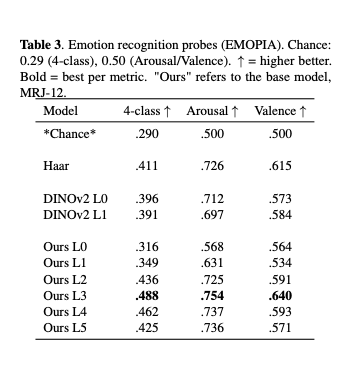


Compare that to a screenshot of the original from the paper where you see the midrules: 

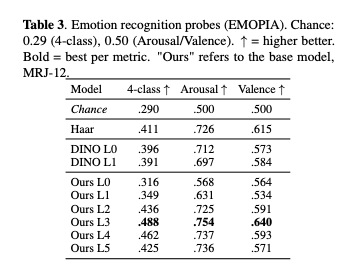



##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

I can't see the two screenshots — this model doesn't support image/png. You could switch to a model like Qwen, Opus, or Gemini Flash via the brain menu in the top nav to enable image support.

That said, from the LaTeX you pasted, the `\midrule` commands are clearly present and look correct. A few things that could cause them not to render in the PDF:

1. **`\booktabs` package not loaded** — `\midrule` requires `\usepackage{booktabs}`. If it's missing, the rules silently fail or produce errors that pdflatex might skip.

2. **`\small` and `\setlength{\tabcolsep}{4pt}` placement** — these appear between `\label` and `\begin{tabular}`. That's valid, but if the booktabs commands somehow ended up outside the tabular environment, they wouldn't render.

Could you check whether `\usepackage{booktabs}` is in the preamble of the generated `.tex` file? The `export_ipynb_to_tex` function does include it in the hardcoded header:

```python
final = '\\documentclass{article}\n\\usepackage{graphicx}\n\\usepackage{booktabs}\n'
```

But if you're using a custom raw preamble that overrides `\documentclass`, the booktabs line might get lost. Can you check the top of the generated `.tex`?

The book tabs package is loaded. In fact, it was being loaded twice. I changed it now so it's only loaded once, but it didn't change anything.  And we already know that book tabs is loaded. because our other tables are rendering okay. 

> That's valid, but if the booktabs commands somehow ended up outside the tabular environment, they wouldn't render.

huh? I just showed you above the exact code we got. the \midrules are within the tabluar environment. 


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right, I can see the `\midrule` commands are clearly inside `\begin{tabular}...\end{tabular}` in the LaTeX you pasted. Sorry for the misdirection.

Let me look more carefully at your `parse_table` function. The issue is likely in how `| ---` rows are detected. In `parse_table`:

```python
if r.strip() == '| ---': rows.append(None)
```

That checks for *exactly* `| ---` (after strip). But in the Markdown, you're probably writing something like `| --- |` or `| --- | --- |` etc. — with trailing pipes and/or multiple columns. That would never match `| ---` exactly, so those rows would be parsed as regular data rows (with empty or `---` cell values) rather than `None` (which triggers `\midrule`).

Could you check what the actual `| ---` line looks like in your Markdown source? If it has trailing pipes, that's the bug — the check needs to be broadened.

Again, the issue is not the parsing, because I showed you the exact LaTeX that's in the file and it's still not rendering. Our LaTeX now literally says \midrule But we're not getting a mid-rule. That's not a parsing problem, that's some kind of rendering problem.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right, I apologize — the `\midrule` is right there in the LaTeX, inside the tabular. This is a rendering issue, not a parsing issue.

A couple of things to check:

1. **Does the pdflatex log show any warnings** related to those midrules? Sometimes booktabs produces warnings like "Misplaced \midrule" that don't halt compilation but cause the rule to be skipped.

2. **Is there a `\\` immediately before each `\midrule`?** Looking at `make_table`, data rows end with ` \\` and then `\midrule` follows on the next line — that should be fine. But could you double-check the actual `.tex` file to make sure there isn't a missing `\\` or an extra blank line between the last data row and `\midrule`? A blank line inside a tabular can cause issues.

Could you check the pdflatex log output for warnings? You could also try running `compile_latex` without `-halt-on-error` to see if there are any non-fatal warnings being suppressed.

No, I apologize. My mistake. Turns out the mid-rules aren't there in the generated LaTeX. I must have copied the source file twice. Here's what's actually generated: 
```
\label{tab:probes-emotion}
\begin{tabular}{lccc}
\toprule
Model & 4-class $\uparrow$ & Arousal $\uparrow$ & Valence $\uparrow$ \\
\midrule
*Chance* & .290 & .500 & .500 \\
 \\
Haar & .411 & .726 & .615 \\
 \\
DINOv2 L0 & .396 & .712 & .573 \\
DINOv2 L1 & .391 & .697 & .584 \\
 \\
Ours L0 & .316 & .568 & .564 \\
Ours L1 & .349 & .631 & .534 \\
Ours L2 & .436 & .725 & .591 \\
Ours L3 & \textbf{.488} & \textbf{.754} & \textbf{.640} \\
Ours L4 & .462 & .737 & .593 \\
Ours L5 & .425 & .736 & .571 \\
\bottomrule
\end{tabular}
\end{table}
```
So we have blank lines where we should have mid-rules.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Now I can see it — this confirms it *is* a parsing issue after all. The `\midrule` rows are being output as empty ` \\` instead.

The culprit is in `parse_table`:

```python
if r.strip() == '| ---': rows.append(None)
```

That only matches the literal string `| ---` — nothing else. Your Markdown probably has `| --- |` or similar with trailing pipes/columns, so it never matches, and the row falls through to the `else` branch where it gets parsed as a regular (empty) data row.

The fix is to broaden that check. Something like: split the row by `|`, strip each cell, and if all cells are `---`, append `None`.

Well, my markdown has exactly that string in it and nothing else on those lines: 
```
| Model | 4-class $\uparrow$ | Arousal $\uparrow$ | Valence $\uparrow$ |
|:--|:--:|:--:|:--:|
| *Chance* | .290 | .500 | .500 |
| ---
| Haar | .411 | .726 | .615 |
| ---
| DINOv2 L0 | .396 | .712 | .573 |
| DINOv2 L1 | .391 | .697 | .584 |
| ---
| Ours L0 | .316 | .568 | .564 |
| Ours L1 | .349 | .631 | .534 |
| Ours L2 | .436 | .725 | .591 |
| Ours L3 | **.488** | **.754** | **.640** |
| Ours L4 | .462 | .737 | .593 |
| Ours L5 | .425 | .736 | .571 |
*Emotion recognition probes (EMOPIA). Chance: 0.29 (4-class), 0.50 (Arousal/Valence). $\uparrow$ = higher better. Bold = best per metric. "Ours" refers to the base model, MRJ-12.* \{#probes-emotion}
``` 
Not even any trailing spaces on those lines we want. We could definitely change the equal sign to a starts with, but not sure.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me test this directly to see what's happening:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;test_md = r\&quot;\&quot;\&quot;| Model | 4-class $\\uparro…&quot;)→&quot;0 [&#x27;*Chance*&#x27;, &#x27;.290&#x27;, &#x27;.500&#x27;, &#x27;.500&#x27;]\n1…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-858146fcbae1daeb",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "test_md = r\"\"\"| Model | 4-class $\\uparrow$ | Arousal $\\uparrow$ | Valence $\\uparrow$ |\n|:--|:--:|:--:|:--:|\n| *Chance* | .290 | .500 | .500 |\n| ---\n| Haar | .411 | .726 | .615 |\n| ---\n| DINOv2 L0 | .396 | .712 | .573 |\n| DINOv2 L1 | .391 | .697 | .584 |\n| ---\n| Ours L0 | .316 | .568 | .564 |\n| Ours L1 | .349 | .631 | .534 |\n| Ours L2 | .436 | .725 | .591 |\n| Ours L3 | **.488** | **.754** | **.640** |\n| Ours L4 | .462 | .737 | .593 |\n| Ours L5 | .425 | .736 | .571 |\n*caption* \\{#probes-emotion}\n\"\"\"\ntd = parse_table(test_md)\nfor i,r in enumerate(td['rows']): print(i, repr(r))"
    }
  },
  "result": "0 ['*Chance*', '.290', '.500', '.500']\n1 None\n2 ['Haar', '.411', '.726', '.615']\n3 None\n4 ['DINOv2 L0', '.396', '.712', '.573']\n5 ['DINOv2 L1', '.391', '.697', '.584']\n6 None\n7 ['Ours L0', '.316', '.568', '.564']\n8 ['Ours L1', '.349', '.631', '.534']\n9 ['Ours L2', '.436', '.725', '.591']\n10 ['Ours L3', '**.488**', '**.754**', '**.640**']\n11 ['Ours L4', '.462', '.737', '.593']\n12 ['Ours L5', '.425', '.736', '.571']"
}
```

</details>

`parse_table` works correctly — `None` rows are in the right places for `\midrule`. So the problem is downstream. Let me check `make_table`:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;print(make_table(td))&quot;)→&quot;\\begin{table}[htbp]\n\\centering\n\\caption{…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-b1069f8befdec124",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "print(make_table(td))"
    }
  },
  "result": "\\begin{table}[htbp]\n\\centering\n\\caption{caption}\n\\label{tab:probes-emotion}\n\\begin{tabular}{lccc}\n\\toprule\nModel & 4-class $\\uparrow$ & Arousal $\\uparrow$ & Valence $\\uparrow$ \\\\\n\\midrule\n*Chance* & .290 & .500 & .500 \\\\\n\\midrule\nHaar & .411 & .726 & .615 \\\\\n\\midrule\nDINOv2 L0 & .396 & .712 & .573 \\\\\nDINOv2 L1 & .391 & .697 & .584 \\\\\n\\midrule\nOurs L0 & .316 & .568 & .564 \\\\\nOurs L1 & .349 & .631 & .534 \\\\\nOurs L2 & .436 & .725 & .591 \\\\\nOurs L3 & \\textbf{.488} & \\textbf{.754} & \\textbf{.640} \\\\\nOurs L4 & .462 & .737 & .593 \\\\\nOurs L5 & .425 & .736 & .571 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}"
}
```

</details>

So `parse_table` and `make_table` both work perfectly. The `\midrule` commands are there. The problem must be in `export_ipynb_to_tex` — specifically in how it collects table lines before passing them to `parse_table`. Let me check that table-collection logic:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;# Simulate what export_ipynb_to_tex does…&quot;)→&quot;Collected 15 table lines:\n&#x27;| Model | 4-c…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-b5bdc6f2bc934332",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "# Simulate what export_ipynb_to_tex does: it collects lines starting with '|'\n# but '| ---' starts with '|' so it should be included...\n# Let's check the actual collection logic\n\nlines = test_md.strip().split('\\n')\ntable_lines = []\ni = 0\nwhile i < len(lines) and lines[i].startswith('|'):\n    table_lines.append(lines[i])\n    i += 1\nprint(f\"Collected {len(table_lines)} table lines:\")\nfor l in table_lines: print(repr(l))"
    }
  },
  "result": "Collected 15 table lines:\n'| Model | 4-class $\\\\uparrow$ | Arousal $\\\\uparrow$ | Valence $\\\\uparrow$ |'\n'|:--|:--:|:--:|:--:|'\n'| *Chance* | .290 | .500 | .500 |'\n'| ---'\n'| Haar | .411 | .726 | .615 |'\n'| ---'\n'| DINOv2 L0 | .396 | .712 | .573 |'\n'| DINOv2 L1 | .391 | .697 | .584 |'\n'| ---'\n'| Ours L0 | .316 | .568 | .564 |'\n'| Ours L1 | .349 | .631 | .534 |'\n'| Ours L2 | .436 | .725 | .591 |'\n'| Ours L3 | **.488** | **.754** | **.640** |'\n'| Ours L4 | .462 | .737 | .593 |'\n'| Ours L5 | .425 | .736 | .571 |'"
}
```

</details>





The pipeline works correctly in isolation. Let me check the actual `export_ipynb_to_tex` code as it currently exists in the kernel — it may have been modified since the version shown in the dialog:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;import inspect\nprint(inspect.getsource(e…&quot;)→&quot;def export_ipynb_to_tex(ipynb_path: str,…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-bbaf0770732c75f7",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import inspect\nprint(inspect.getsource(export_ipynb_to_tex))"
    }
  },
  "result": "def export_ipynb_to_tex(ipynb_path: str, output_path: str = None, ordered=True):\n    r\"\"\"Export a Solveit dialog (.ipynb) to a compilable LaTeX file.\n    Cells are emitted in document order, each preceded by a `% <cell-id>` comment.\n    The `## Abstract` cell emits `\\begin{document}`, dividing preamble from document body.\"\"\"\n\n    ipynb_path = os.path.expanduser(ipynb_path)\n\n    if ordered:  # Export preserving \"#| replaces\" ordering. Writes to -out.ipynb first. That becomes the input file \n        ipynb_path = export_ordered(ipynb_path)\n\n    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')\n    if ordered: output_path = str(output_path).replace('-out.tex', '.tex')\n    print(\"output_path =\",output_path)\n\n    nb = json.loads(Path(ipynb_path).read_text())\n    out = []\n\n    for cell in nb['cells']:\n        content = ''.join(cell['source'])\n        content = md_to_latex_bold(content)\n\n\n        if '#| export' not in content:\n            continue\n\n        filtered = '\\n'.join(l for l in content.split('\\n') if not l.startswith('#| '))\n        out.append(f'% {cell[\"id\"]}')\n\n        if cell['cell_type'] == 'raw':\n            out.append(filtered)\n            continue\n\n        lines = filtered.split('\\n')\n        i = 0\n        while i < len(lines):\n            line = lines[i]\n\n            if line.startswith('# ') and not line.startswith('## '):\n                out.append(f'\\\\title{{{line[2:].strip()}}}\\n')\n            elif line.startswith('\\\\author{'):\n                out.append(line)\n                while i < len(lines) and not lines[i].strip().endswith('}'):\n                    i += 1\n                    if i < len(lines):\n                        out.append(lines[i])\n            elif line == '## Abstract':\n                out.append('\\\\begin{document}\\n\\n\\\\maketitle\\n')\n                out.append('\\\\begin{abstract}\\n')\n                i += 1\n                while i < len(lines) and not lines[i].startswith('## '):\n                    out.append(lines[i])\n                    i += 1\n                out.append('\\\\end{abstract}\\n')\n                continue\n            elif line == '## References':\n                out.append('\\\\small\\n')\n                i += 1\n                while i < len(lines) and not lines[i].startswith('## '):\n                    l = lines[i]\n                    if l.strip().startswith('\\\\bibliographystyle'):\n                        out.append(l + '\\n')\n                    bib_match = re.search(r'(\\w+)\\.bib', l)\n                    if bib_match:\n                        out.append(f'\\\\bibliography{{{bib_match.group(1)}}}\\n')\n                    i += 1\n                continue\n            elif line.startswith('### '):\n                out.append(f'\\\\subsection{{{line[4:].strip()}}}\\n')\n            elif line.startswith('## '):\n                out.append(f'\\\\section{{{line[3:].strip()}}}\\n')\n            elif line.startswith('|'):    # table handling\n                # Collect table lines\n                table_lines = []\n                while i < len(lines) and lines[i].startswith('|'):\n                    table_lines.append(lines[i])\n                    i += 1\n                # Check for caption line\n                if i < len(lines) and re.match(r'\\s*\\*', lines[i]):\n                    table_lines.append(lines[i])\n                    i += 1\n                # Parse and convert\n                tbl_dict = parse_table(table_lines)\n                if tbl_dict:\n                    out.append(make_table(tbl_dict))\n                continue  # Skip the i += 1 at the end    \n            else:         # figures\n                fig_dict = parse_figure(line)\n                if fig_dict:\n                    out.append(make_figure(fig_dict))\n                else:\n                    out.append(line)\n\n            i += 1\n\n    final = '\\\\documentclass{article}\\n\\\\usepackage{graphicx}\\n\\\\usepackage{booktabs}\\n'\n    final += '\\n'.join(out) + '\\n\\n'\n    final += '\\\\end{document}\\n'\n    final = md_to_latex_italic(final)\n\n    Path(output_path).write_text(final)\n    print(f'Created {output_path}')\n    output_url = get_private_url(output_path)\n    display(HTML(f'<a href=\"{output_url}\" target=\"_blank\">{output_url}</a>'))"
}
```

</details>





*[Response interrupted]*